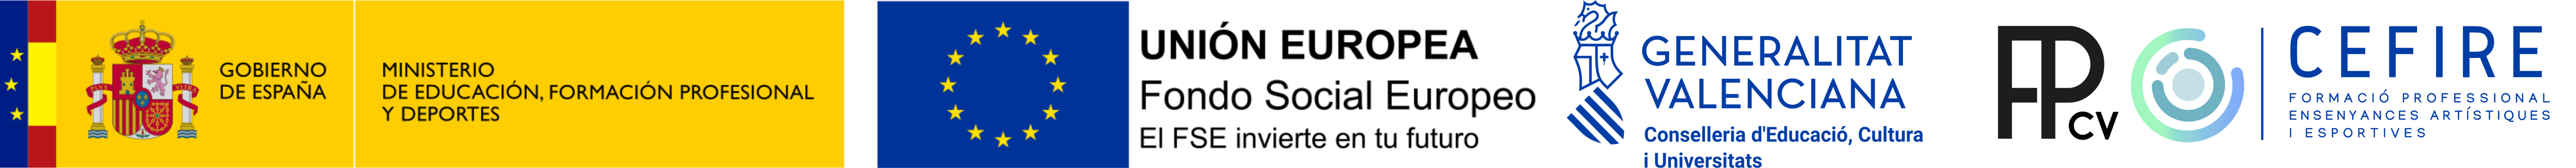

Vamos  crear una Web App que permita en base al tamaño del motor, los cilindros y el consumo indicar cual será el **consumo estimado de CO2**:

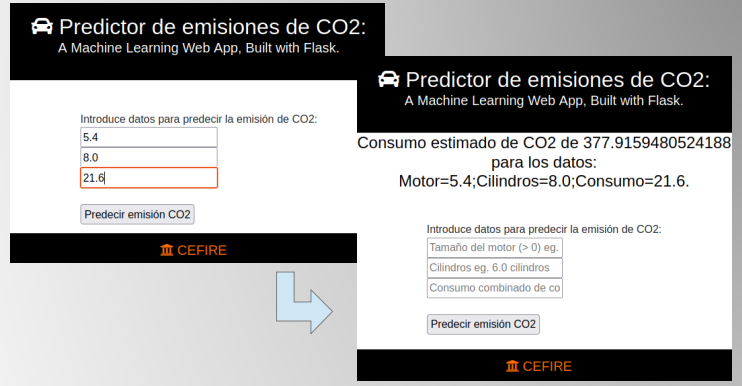

#### Para conseguirlo en este notebook nos centraremos en  crear un modelo que la webapp pueda utilizar realizando los siguientes pasos:
####     1.- Preparar el Dataset
####     2-  Crear los datos de entrenamiento y test
####     3-  Entrenar (train)
####     4-  Predecir con los datos de test
####     5-  Evaluar el modelo: Métricas
####     6-  Predecir simulando una entrada vía web  <-- Guiado
####     7.- Pipelines: Procesar datos de entrada  <-- Guiado
####     8.- Pickle: Persistir modelo  <-- Guiado


El foco de esta práctica no es el modelo, sino la **arquitectura** que implementaremos para crear una **webapp con Flask** de manera que podamos interactuar con el modelo haciendole preguntas a través de un navegador.


Para nuestra Webapp vamos a utilizar un modelo sencillo ya conocido, un **modelo de regresión múltiple** que nos permitia en base al tamaño del motor (Enginesize), el número de cilindros (Cylinders) y el consumo de carburante (FuelConsumption_Comb) predecir el CO2 que emitiamos (CO2Emissions):


**CO2EMISSIONS ≈ β₀ + β₁*ENGINESIZE + β₂*CYLINDERS + β₃*FUELCONSUMPTION_COMB**

### 1.- Preparar el Dataset

 Prepara el Dataset como lo hemos hecho en la práctica guiada:

In [2]:
# EJECUTAR ESTA CELDA SI ESTAMOS EN JUPYTER NOTEBOOK O VSCODE EN LOCAL:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   MODELYEAR                 1067 non-null   int64  
 1   MAKE                      1067 non-null   object 
 2   MODEL                     1067 non-null   object 
 3   VEHICLECLASS              1067 non-null   object 
 4   ENGINESIZE                1067 non-null   float64
 5   CYLINDERS                 1067 non-null   int64  
 6   TRANSMISSION              1067 non-null   object 
 7   FUELTYPE                  1067 non-null   object 
 8   FUELCONSUMPTION_CITY      1067 non-null   float64
 9   FUELCONSUMPTION_HWY       1067 non-null   float64
 10  FUELCONSUMPTION_COMB      1067 non-null   float64
 11  FUELCONSUMPTION_COMB_MPG  1067 non-null   int64  
 12  CO2EMISSIONS              1067 non-null   int64  
dtypes: float64(4), int64(4), object(5)
memory usage: 108.5+ KB


In [4]:
# Seleccionar columnas de interés

### 2- Crear los datos de entrenamiento y test
La división entrenamiento/test implicaba dividir el conjunto de datos en conjuntos que son mutuamente excluyentes. Después de lo cual, se entrenaba con el conjunto de entrenamiento y se valida con el conjunto de test.
Esto proporcionaba una evaluación más exacta de la precisión fuera de la muestra, ya que el conjunto de datos de la prueba no formaba parte del conjunto de datos que se utilizaba para entrenar el modelo. Es más realista para los problemas del mundo real.

Prepara los datos de entrenamiento y test:

In [5]:
from sklearn.model_selection import train_test_split

# --- División en Entrenamiento y Prueba ---
# Para la mayoría de los ejemplos, usaremos múltiples características

In [6]:
print(f"Tamaño del conjunto de entrenamiento (múltiple): {X_train_multi.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (múltiple): {X_test_multi.shape[0]} muestras")

Tamaño del conjunto de entrenamiento (múltiple): 853 muestras
Tamaño del conjunto de prueba (múltiple): 214 muestras


### 3- Entrenar (train)
Realizamos el entrenamiento con una regresión lineal múltiple:

In [7]:
from sklearn.linear_model import LinearRegression

# Regresión Lineal Múltiple
# 1. Crear instancia del modelo

# 2. Entrenar el modelo

LinearRegression()

### 4- Predecir con los datos de test
Realizamos el entrenamiento con una regresión lineal múltiple:

In [8]:
# 4. Predecir en el conjunto de prueba

### 5- Evaluar el modelo: Métricas
Evaluamos su rendimiento:

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# 5. Evaluar e interpretar métricas


--- Evaluación del Modelo Múltiple (sobre datos de prueba) ---

--- Evaluación (Múltiple) ---
MSE: 512.86
RMSE: 22.65
R²: 0.8760


### 6- Predecir simulando una entrada vía web  <-- Guiado

Creamos una entrada nueva y se la pasamos al predictor. Esto será lo que tendremos que hacer con el modelo cuando interactuemos via web realizandole consultas:

In [10]:
X_web = pd.DataFrame([[1.4, 4.0, 7.8]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB'])
p_pred_web = lin_reg_multi.predict(X_web)
p_pred_web[0]# quitamos corchetes de p_pred=[185.92...]

185.92638775794975

### 7.- Pipelines: Procesar datos de entrada  <-- NOVEDAD

En algunos casos es conveniente preprocesar los datos de entrada y esto nos obliga a crear un pipeline que irá aplicando cada uno de los preprocesos. En este caso tan simplificado solo se preprocesa pasando los datos de entrada por el modelo, pero podríamos crear un pipepile con tantas lineas de preprocesamiento como preprocesos tenga (por ejemplo para normalizar):

In [11]:
from sklearn.pipeline import Pipeline
# Construimos un pipeline con los pasos a realizar sobre los datos:
pipeline = Pipeline([
    ('regressor', lin_reg_multi)
])

El pipeline se utiliza para realizar predicciones en nuevos datos, asegurándose de aplicar la misma transformación a las características que se utilizó durante el entrenamiento del modelo.

In [12]:
X_train_multi.iloc[0]

ENGINESIZE              1.4
CYLINDERS               4.0
FUELCONSUMPTION_COMB    7.8
Name: 333, dtype: float64

Comprobemos que devuelve algo adecuado:

In [13]:
print(X_train_multi.iloc[0])
prediction = pipeline.predict(pd.DataFrame([X_train_multi.iloc[0]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']))
print(prediction[0])

ENGINESIZE              1.4
CYLINDERS               4.0
FUELCONSUMPTION_COMB    7.8
Name: 333, dtype: float64
185.92638775794975


In [14]:
prediction

array([185.92638776])

Simulando que introducimos manualmente los valores de las columnas para ser procesadas por el pipeline vemos que obtenemos el mismo resultado:

In [15]:
prediction = pipeline.predict(pd.DataFrame([[1.4, 4.0, 7.8]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']))
prediction[0]

185.92638775794975

### 8.- Pickle: Persistir modelo  <-- NOVEDAD

Necesitamos un archivo que pueda ser utilizado para cargar el modelo y realizar predicciones sin tener que volver a entrenar el modelo desde cero en nuestra web:

In [16]:
import pickle
with open('pipeline.pickle','wb') as f: #Abrimos archivo en modo escritura binaria
    pickle.dump(pipeline, f) #Guardamos objeto pipeline a un archivo binario

En el backend de nuestra webapp en Flask necesitaremos poder recuperar el modelo que hemos guardado en un archivo binario de manera similar a como se muestra a continuación:

In [17]:
#Cargamos el pipeline desde el archivo pickle con el nombre "loaded_pipe"
with open('pipeline.pickle','rb') as f:
    loaded_pipe = pickle.load(f)
#comprobamos realizando una nueva predicción con el pipeline
prediction = loaded_pipe.predict(pd.DataFrame([[1.4, 4.0, 7.8]], columns=['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB']))
prediction[0]


185.92638775794975

**Desde el notebook ya tenemos todo lo necesario para realizar nuestra 1º webapp que utiliza un modelo de Machine Learning**